# Data Processing

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

import nwec.utility_reporting.arrearage_counts
import nwec.utils.excel
from nwec.constants import CLEAN_UTILITY_DATA, MONTHS, RAW_UTILITY_DATA

In [2]:
spreadsheet = RAW_UTILITY_DATA / "IOU_arrearage counts.xlsx"
sheet_name = "Past Due Balances"
sheet_index = nwec.utils.excel.get_sheet_index_from_name(spreadsheet, sheet_name)
df = pl.read_excel(spreadsheet, sheet_id=sheet_index, has_header=False)

# Get rid of the first row and promote the second to be the DataFrame header
headers = df.slice(1, 1).row(0)
df = df.slice(2).rename(dict(zip(df.columns, [str(col) for col in headers], strict=True)))


In [3]:
index_cols = [col for col in df.columns if col not in MONTHS]
# Unpivot the month and year columns into a single "YYYY-MM" column with corresponding "Arrearage Count" values
df = df.unpivot(on=MONTHS, index=index_cols, variable_name="Month", value_name="Arrearage Count")
df = df.with_columns(
    (pl.col("Year") + "-" + pl.col("Month").str.to_datetime("%B").dt.month().cast(pl.Utf8).str.zfill(2)).alias("Month")
).drop("Year")
df = df.with_columns(pl.col("Month").str.strptime(pl.Date, "%Y-%m").alias("Month"))

In [4]:
# Filter for residential customers and clean up the "Arrearage Count" column
df = df.filter(pl.col("Customer Class").str.contains(r"(?i)res")).drop("Customer Class")
df = df.with_columns(
    pl.when(pl.col("Arrearage Count").str.strip_chars() == "")
    .then(None)
    .otherwise(pl.col("Arrearage Count"))
    .alias("Arrearage Count")
)
df = df.drop_nulls(subset=["Arrearage Count"]).cast({"Arrearage Count": pl.Int64})

In [5]:
nwec.utility_reporting.arrearage_counts.save_arrearage_counts(df)
df.head(3)

Utility,Zip Code,Month,Arrearage Count
str,str,date,i64
"""Avista""","""98620""",2025-01-01,86
"""Avista""","""98648""",2025-01-01,18
"""Avista""","""98857""",2025-01-01,2


# Data Analysis

In [6]:
arrearage_counts = pl.read_ipc(CLEAN_UTILITY_DATA / "arrearage_counts.arrow")


In [7]:
arrearage_counts.sum()

Utility,Zip Code,Month,Arrearage Count
str,str,date,i64
null,null,null,1801615


In [8]:
arrearage_counts.group_by("Month").agg(pl.sum("Arrearage Count")).sort("Month")

Month,Arrearage Count
date,i64
2025-01-01,311525
2025-02-01,311031
2025-03-01,329231
2025-04-01,282985
2025-05-01,294969
2025-06-01,271874


In [9]:
arrearage_counts.group_by("Utility").agg(pl.sum("Arrearage Count")).sort("Utility")

Utility,Arrearage Count
str,i64
"""Avista""",165441
"""CNG""",113639
"""NWN""",75558
"""PAC""",172864
"""PSE""",1274113


In [10]:
arrearage_counts.group_by("Utility", "Month").agg(pl.sum("Arrearage Count")).sort(["Utility", "Month"])

Utility,Month,Arrearage Count
str,date,i64
"""Avista""",2025-01-01,25299
"""Avista""",2025-02-01,24577
"""Avista""",2025-03-01,27875
"""Avista""",2025-04-01,27603
"""Avista""",2025-05-01,30359
…,…,…
"""PSE""",2025-02-01,232214
"""PSE""",2025-03-01,239463
"""PSE""",2025-04-01,191294


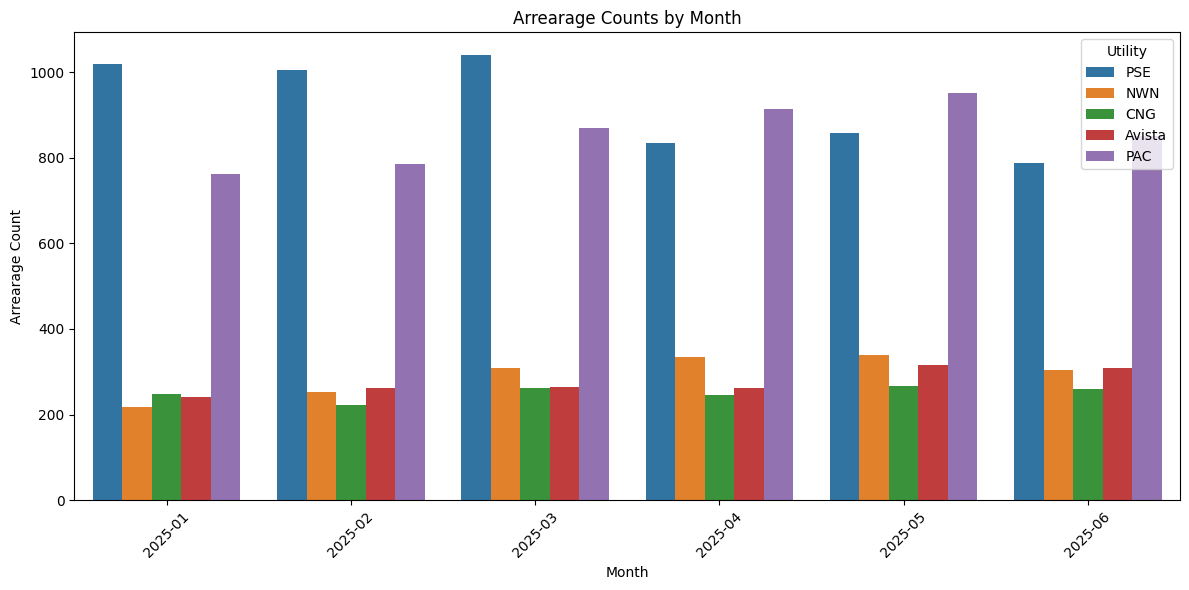

In [ ]:
# Create a properly sorted version for plotting with YYYY-MM format labels
plot_data = (
    arrearage_counts.with_columns(pl.col("Month").dt.strftime("%Y-%m").alias("Month_Label")).sort("Month").to_pandas()
)

plt.figure(figsize=(12, 6))
sns.barplot(x="Month_Label", y="Arrearage Count", hue="Utility", data=plot_data, errorbar=None)
plt.title("Arrearage Counts by Month")
plt.xlabel("Month")
plt.ylabel("Arrearage Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()